# Анализ лояльности пользователей Яндекс Афиши

Автор: Екатерина Лобач
Дата: 07.11.2025

## Цели и задачи проекта
### Цель: Провести исследовательский анализ лояльности пользователей Яндекс Афиши для выявления факторов, влияющих на повторные покупки.

### Задачи:

1. Загрузить данные и провести их первичный осмотр.
2. Провести предобработку данных.
3. Провести исследовательский анализ данных:
   - Проанализировать воронку событий от первого визита до покупки.
   - Рассчитать и проанализировать ключевые метрики лояльности.
   - Провести сегментацию пользователей.
   - Исследовать, как различные характеристики пользователей (источник привлечения, география, поведение) влияют на их возвращаемость.
4. Сформулировать выводы и практические рекомендации для команды маркетинга по повышению лояльности пользователей.

## Описание данных
Схема afisha базы данных data-analyst-afisha содержит пять таблиц.

**Содержимое таблиц:**

**Таблица purchases**

Содержит информацию о заказах билетов:
  - order_id — идентификатор заказа;
  - user_id — идентификатор пользователя, совершившего заказ;
  - created_dt_msk — дата создания заказа по московскому времени;
  - created_ts_msk — дата и время создания заказа по московскому времени;
  - event_id — идентификатор мероприятия из таблицы events;
  - cinema_circuit — сеть кинотеатров, где проходит мероприятие. Если оно проходит не в кинотеатре, то здесь будет значение нет;
  - age_limit — возрастное ограничение мероприятия;
  - currency_code — валюта оплаты;
  - device_type_canonical — тип устройства, с которого был оформлен заказ (например, mobile — мобильные устройства, desktop — компьютеры);
  - revenue — выручка от заказа;
  - service_name — название билетного оператора;
  - tickets_count — количество купленных билетов;
  - total — общая сумма заказа.
  
**Таблица events**

Содержит данные о мероприятиях, доступных на платформе:
  - event_id — идентификатор мероприятия.
  - event_name_code — название мероприятия в закодированном виде.
  - event_type_description — описание мероприятия.
  - event_type_main — основной тип мероприятия (театральная постановка, концерт и так далее)
  - organizers — организаторы мероприятия.
  - city_id — идентификатор города проведения мероприятия из таблицы cities.
  - venue_id — идентификатор площадки проведения мероприятия из таблицы venues.

**Таблица venues**

Содержит сведения о площадках проведения мероприятий:
  - venue_id — идентификатор площадки;
  - venue_name — название площадки;
  - address — адрес площадки.
  
**Таблица city**

Содержит список городов, относящихся к регионам:
  - city_id — идентификатор города;
  - city_name — название города;
  - region_id — идентификатор региона, в котором расположен город, из таблицы regions.
  
**Таблица regions**

Содержит список регионов, в которых проводятся мероприятия:
  - region_id — идентификатор региона;
  - region_name — название региона.

**Взаимосвязь между таблицами.**
  - Все связи — «один ко многим».
  - Нет связей «один к одному» или «многие ко многим».
  - Первичные ключи: region_id, city_id, venue_id, event_id, order_id.
  - Внешние ключи:
      - events.city_id → city.city_id
      - events.venue_id → venues.venue_id
      - city.region_id → regions.region_id
      - purchases.event_id → events.event_id

Такая структура типична для транзакционных систем с иерархической организацией данных: регион → город → площадка/мероприятие → заказ.


## Содержимое проекта
1. Загрузка данных и знакомство с ними.
2. Предобработка данных.
3. Исследовательский анализ данных.
4. Итоговые выводы.
5. Публикация проекта в Git.

## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка

---

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. Используйте следующие параметры для подключения к базе данных `data-analyst-afisha`:

- **Хост** — `rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net`
- **База данных** — `data-analyst-afisha`
- **Порт** — `6432`
- **Аутентификация** — `Database Native`
- **Пользователь** — `praktikum_student`
- **Пароль** — `Sdf4$2;d-d30pp`

Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---


In [12]:
# установка SQLAlchemy
!pip install sqlalchemy 

In [13]:
# установка модуля psycopg2
!pip install psycopg2-binary 

In [14]:
# установка pandas и функция create_engine() из библиотеки SQLAlchemy
import pandas as pd
from sqlalchemy import create_engine 

In [15]:
# Подключение к базе данных
db_config = {'user': 'praktikum_student', # имя пользователя
             'pwd': 'Sdf4$2;d-d30pp', # пароль
             'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
             'port': 6432, # порт подключения
             'db': 'data-analyst-afisha' # название базы данных
             } 


In [16]:
#  строка для подключения
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
) 


In [17]:
# создание соединение, строка с данными для подключения передается функции create_engine()
engine = create_engine(connection_string) 

In [18]:
# Извлечение результатов SQL-запроса
query = '''
-- Настройка параметра synchronize_seqscans важна для проверки
WITH set_config_precode AS (
    SELECT set_config('synchronize_seqscans', 'off', true)
)
-- Напишите ваш запрос ниже
SELECT 
    p.user_id,
    p.device_type_canonical,
    p.order_id,
    p.created_dt_msk as order_dt,
    p.created_ts_msk as order_ts,
    p.currency_code,
    p.revenue,
    p.tickets_count,
    (p.created_dt_msk::DATE - LAG(p.created_dt_msk::DATE) OVER (
        PARTITION BY p.user_id 
        ORDER BY p.created_dt_msk
    )) AS days_since_prev,
    e.event_id,
    e.event_name_code AS event_name,
    e.event_type_main,
    p.service_name,
    r.region_name,
    c.city_name
FROM afisha.purchases AS p
INNER JOIN afisha.events AS e ON p.event_id = e.event_id
JOIN afisha.city AS c ON e.city_id = c.city_id
JOIN afisha.regions AS r ON c.region_id = r.region_id
WHERE 
    p.device_type_canonical IN ('mobile', 'desktop')
    AND LOWER(e.event_type_main) != 'фильм'
ORDER BY p.user_id
''' 


In [19]:
# Запись результата выдачи SQL-запроса в датафрейм 
df = pd.read_sql_query(query, con=engine) 

---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

In [20]:
# Выводим первые строки датафрейма на экран
df.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк


In [21]:
# Выводим информацию о датафрейме
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

**Промежуточный вывод**

Датасет содержит 290 611 записей и 15 столбцов с данными о взаимодействиях пользователей с сервисом Яндекс Афиша.

После первичного анализа данных можно сделать следующие выводы:

**Структура данных:** Данные представлены в различных форматах - временные метки (datetime64[ns]), числовые (float64, int64) и категориальные признаки (object). Наличие временных меток order_dt и order_ts позволяет проводить временной анализ.

**Полнота данных:** Большинство столбцов не содержат пропусков, что свидетельствует о хорошем качестве данных. Исключение составляет столбец days_since_prev, в котором отсутствует 21 933 значения (290 611 - 268 678 = 21 933), что составляет примерно 7.5% от общего объема данных.

**Ключевые метрики:** В данных присутствуют важные для анализа лояльности показатели:

  - revenue - финансовый результат заказов
  - tickets_count - количество билетов в заказе
  - days_since_prev - время между заказами (ключевой показатель для анализа возвращаемости)

**Сегментационные признаки:** Доступны данные для сегментации пользователей по:

  - Устройствам (device_type_canonical)
  - Географии (region_name, city_name)
  - Типам событий (event_name, event_type_main)
  - Сервисам (service_name)

Датасет хорошо подходит для проведения анализа лояльности, так как содержит необходимые временные метки, финансовые показатели и признаки для сегментации пользователей.

---

###  2. Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


In [30]:
# Загрузка курсов тенге к рублю за 2024 год
tenge_rates_df = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv',
    parse_dates=['data'])

In [36]:
tenge_rates_df.head()

,order_date,curs
0,2024-01-10,19.9391
1,2024-01-11,19.7255
2,2024-01-12,19.5839
3,2024-01-13,19.4501
4,2024-01-14,19.4501


In [33]:
# Приведение названий валют к нижнему регистру (на случай разного написания)
df['currency_code'] = df['currency_code'].str.lower()

# Проверка, что все валюты — только rub или kzt
assert df['currency_code'].isin(['rub', 'kzt']).all(), "Обнаружены валюты, отличные от rub/kzt"

# Преобразуем дату заказа к дате без времени
df['order_date'] = df['order_dt'].dt.normalize()

# Подготовка датасета с курсами: оставляем нужные столбцы и переименовываем
tenge_rates_df = tenge_rates_df[['data', 'curs']].rename(columns={'data': 'order_date'})

# Объединяем с основным датафреймом по дате
df = df.merge(tenge_rates_df, on='order_date', how='left')

# Конвертация выручки в рубли
df['revenue_rub'] = df.apply(
    lambda row: row['revenue'] if row['currency_code'] == 'rub'
                else row['revenue'] / 100 * row['curs'],
    axis=1
)

---

**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

In [37]:
# Проверяем данные на пропущенные значения
df.isna().sum()

user_id                      0
device_type_canonical        0
order_id                     0
order_dt                     0
order_ts                     0
currency_code                0
revenue                      0
tickets_count                0
days_since_prev          21933
event_id                     0
event_name                   0
event_type_main              0
service_name                 0
region_name                  0
city_name                    0
order_date                   0
curs                         0
revenue_rub                  0
dtype: int64

In [38]:
# Проверяем типы данных
df.dtypes

user_id                          object
device_type_canonical            object
order_id                          int64
order_dt                 datetime64[ns]
order_ts                 datetime64[ns]
currency_code                    object
revenue                         float64
tickets_count                     int64
days_since_prev                 float64
event_id                          int64
event_name                       object
event_type_main                  object
service_name                     object
region_name                      object
city_name                        object
order_date               datetime64[ns]
curs                            float64
revenue_rub                     float64
dtype: object

In [39]:
# --- Оптимизация целочисленных столбцов ---
# Используем downcast для подбора минимально возможного типа
df['order_id'] = pd.to_numeric(df['order_id'], downcast='integer')
df['event_id'] = pd.to_numeric(df['event_id'], downcast='integer')
df['tickets_count'] = pd.to_numeric(df['tickets_count'], downcast='integer')

# --- Оптимизация вещественных столбцов ---
df['revenue'] = pd.to_numeric(df['revenue'], downcast='float')
df['revenue_rub'] = pd.to_numeric(df['revenue_rub'], downcast='float')
df['days_since_prev'] = pd.to_numeric(df['days_since_prev'], downcast='float')
df['curs'] = pd.to_numeric(df['curs'], downcast='float')

In [40]:
# Сократим категориальные строки до 'category' (если повторяются часто) ---
# Это особенно эффективно для столбцов с небольшим числом уникальных значений
categorical_cols = [
    'device_type_canonical',
    'currency_code',
    'event_type_main',
    'service_name',
    'region_name',
    'city_name'
]

# Преобразуем только те, у которых уникальных значений < 50% от общего числа строк (адаптивный подход)
for col in categorical_cols:
    if df[col].nunique() / len(df) < 0.5:
        df[col] = df[col].astype('category')

In [41]:
df.dtypes

user_id                          object
device_type_canonical          category
order_id                          int32
order_dt                 datetime64[ns]
order_ts                 datetime64[ns]
currency_code                  category
revenue                         float32
tickets_count                      int8
days_since_prev                 float32
event_id                          int32
event_name                       object
event_type_main                category
service_name                   category
region_name                    category
city_name                      category
order_date               datetime64[ns]
curs                            float32
revenue_rub                     float32
dtype: object

Описательная статистика:
         revenue_rub  tickets_count
count  290611.000000  290611.000000
mean      555.572083       2.754311
std       875.498169       1.170620
min       -90.760002       1.000000
25%       113.970001       2.000000
50%       351.140015       3.000000
75%       802.049988       4.000000
max     81174.539062      57.000000

Количество пропусков:
revenue_rub      0
tickets_count    0
dtype: int64


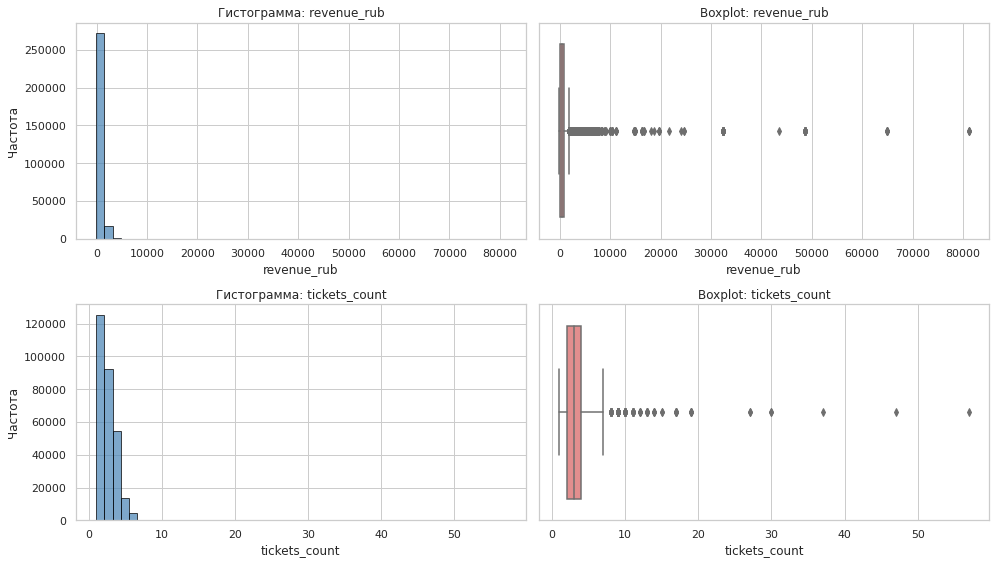


99-й перцентиль revenue_rub: 2,628.42 ₽
Выбросов (revenue_rub > 99%): 2825 строк (0.97%)

Размер датасета до фильтрации: 290,611
Размер датасета после фильтрации: 287,786
Удалено строк: 2,825


In [42]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Указываем стили для графиков
sns.set(style="whitegrid")

# Ключевые числовые столбцы для анализа
numeric_cols = ['revenue_rub', 'tickets_count']

# 1. Статистическое описание
print("Описательная статистика:")
print(df[numeric_cols].describe())
print("\nКоличество пропусков:")
print(df[numeric_cols].isnull().sum())

# 2. Визуализация: гистограммы и boxplot (диаграммы размаха)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for i, col in enumerate(numeric_cols):
    # Гистограмма
    axes[i, 0].hist(df[col].dropna(), bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i, 0].set_title(f'Гистограмма: {col}')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Частота')
    
    # Boxplot (диаграмма размаха)
    sns.boxplot(x=df[col], ax=axes[i, 1], color='lightcoral')
    axes[i, 1].set_title(f'Boxplot: {col}')

plt.tight_layout()
plt.show()

# 3. Проверка на выбросы в revenue_rub и фильтрация по 99-му перцентилю
p99_revenue = df['revenue_rub'].quantile(0.99)
print(f"\n99-й перцентиль revenue_rub: {p99_revenue:,.2f} ₽")

# Определяем, сколько записей будет удалено
outliers_mask = df['revenue_rub'] > p99_revenue
n_outliers = outliers_mask.sum()
total_rows = len(df)
perc_outliers = n_outliers / total_rows * 100

print(f"Выбросов (revenue_rub > 99%): {n_outliers} строк ({perc_outliers:.2f}%)")

# 4. Фильтрация выбросов
df_filtered = df[~outliers_mask].copy()

print(f"\nРазмер датасета до фильтрации: {len(df):,}")
print(f"Размер датасета после фильтрации: {len(df_filtered):,}")
print(f"Удалено строк: {len(df) - len(df_filtered):,}")

In [43]:
# Сохраняем очищенный датасет для дальнейшего анализа
df = df_filtered

**Промежуточный вывод по предобработке данных**

Основные выполенные действия:
    
- Проверка пропущенных значений

Подтверждено, что пропуски присутствуют только в столбце days_since_prev (21 933 строки), что соответствует ожиданиям — это логичное поведение для первого заказа пользователя.
Во всех остальных столбцах — нулевое количество пропусков.

- Оптимизация типов данных

Целочисленные столбцы (order_id, event_id, tickets_count) переведены в минимально возможные типы:
tickets_count → int8 (значения от 1 до 57),
order_id, event_id → int32.

Вещественные столбцы (revenue, revenue_rub, days_since_prev, curs) переведены в float32 — сокращение памяти в 2 раза без потери точности.

Категориальные столбцы (device_type_canonical, currency_code, event_type_main, service_name, region_name, city_name) преобразованы в тип category — это значительно снижает потребление памяти при работе с повторяющимися значениями.

- Анализ распределения ключевых показателей

Проанализированы два ключевых показателя:
   - revenue_rub — выручка с заказа в рублях (целевой показатель).  
   - tickets_count — количество билетов в заказе.

Распределение revenue_rub сильно смещено вправо (большинство заказов — дешёвые, есть редкие дорогие).

Распределение tickets_count — дискретное, с пиком на 2–4 билета, но встречаются заказы до 57 билетов.

- Обработка выбросов в revenue_rub
Выявлены экстремальные значения: максимум — 81 174.54 ₽, тогда как 99-й перцентиль — 2 628.42 ₽.

Удалено 2 825 строк (0.97%) — это заказы с аномально высокой выручкой.

Оставшиеся данные (287 786 строк) более репрезентативны для анализа средних метрик и моделирования.

- Новые/изменённые столбцы:
revenue_rub - Новый столбец — выручка, конвертированная в рубли (единая валюта). Рассчитана на основе курса тенге к рублю за день заказа.

order_date - Вспомогательный столбец — дата заказа без времени, использовался для соединения с 
курсами.

curs - Вспомогательный столбец — курс тенге к рублю за 100 единиц валюты. 

- Визуальный анализ подтвердил:

Гистограммы показали сильную правостороннюю асимметрию у revenue_rub — характерно для финансовых данных.

Boxplot выявил отдельные точки-выбросы (особенно в revenue_rub), которые были удалены.
tickets_count — дискретное распределение с длинным хвостом, но без критических выбросов (не требовал фильтрации).

- Итоговый вывод:

Данные успешно подготовлены к дальнейшему анализу и моделированию. Проведена оптимизация памяти, нормализация категорий, обработка выбросов в ключевом показателе revenue_rub. Удалено менее 1% записей — это не искажает общую картину, но позволяет избежать влияния экстремальных значений на статистические метрики и модели.

---

### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


In [46]:
# Убеждаемся, что данные отсортированы по времени заказа
df = df.sort_values(['user_id', 'order_ts']).reset_index(drop=True)

# Группируем по user_id и агрегируем признаки
user_profile = df.groupby('user_id').agg(
    first_order_date=('order_dt', 'min'),
    last_order_date=('order_dt', 'max'),
    device_first=('device_type_canonical', 'first'),
    region_first=('region_name', 'first'),
    service_first=('service_name', 'first'),
    event_genre_first=('event_type_main', 'first'),
    total_orders=('order_id', 'count'),
    avg_revenue_rub=('revenue_rub', 'mean'),
    avg_tickets=('tickets_count', 'mean'),
    avg_days_between=('days_since_prev', lambda x: x.dropna().mean() if x.dropna().size > 0 else np.nan)
).reset_index()

# Бинарные признаки
user_profile['is_two'] = (user_profile['total_orders'] >= 2).astype(int)
user_profile['is_five'] = (user_profile['total_orders'] >= 5).astype(int)

# Проверка результата
print("Профиль пользователя:")
print(user_profile.head())
print(f"\nРазмер итогового профиля: {user_profile.shape}")

Профиль пользователя:
           user_id first_order_date last_order_date device_first  \
0  0002849b70a3ce2       2024-08-20      2024-08-20       mobile   
1  0005ca5e93f2cf4       2024-07-23      2024-10-06       mobile   
2  000898990054619       2024-07-13      2024-10-23       mobile   
3  00096d1f542ab2b       2024-08-15      2024-08-15      desktop   
4  000a55a418c128c       2024-09-29      2024-10-15       mobile   

           region_first  service_first event_genre_first  total_orders  \
0    Каменевский регион   Край билетов             театр             1   
1    Каменевский регион      Мой билет          выставки             2   
2  Североярская область    Лови билет!            другое             3   
3    Каменевский регион   Край билетов             театр             1   
4      Поленовский край  Лучшие билеты             театр             2   

   avg_revenue_rub  avg_tickets  avg_days_between  is_two  is_five  
0      1521.939941     4.000000               NaN      

---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

In [47]:
# Агрегированные метрики по пользователям
total_users = user_profile['user_id'].nunique()
avg_revenue_per_order = user_profile['avg_revenue_rub'].mean()  # средняя выручка с заказа на уровне пользователей

# Доля пользователей с 2+ и 5+ заказами
share_two_plus = user_profile['is_two'].mean()
share_five_plus = user_profile['is_five'].mean()

# Вывод ключевых метрик
print("Ключевые агрегированные метрики")
print(f"Общее число пользователей: {total_users:,}")
print(f"Средняя выручка с одного заказа: {avg_revenue_per_order:,.2f} ₽")
print(f"Доля пользователей с ≥2 заказами: {share_two_plus:.2%}")
print(f"Доля пользователей с ≥5 заказами: {share_five_plus:.2%}")
print()

# Статистика по числовым признакам профиля 
numeric_stats_cols = ['total_orders', 'avg_tickets', 'avg_days_between']

print("Описательная статистика по профилю пользователей")
print(user_profile[numeric_stats_cols].describe().round(2))

Ключевые агрегированные метрики
Общее число пользователей: 21,854
Средняя выручка с одного заказа: 544.40 ₽
Доля пользователей с ≥2 заказами: 61.71%
Доля пользователей с ≥5 заказами: 29.01%

Описательная статистика по профилю пользователей
       total_orders  avg_tickets  avg_days_between
count      21854.00     21854.00          13513.00
mean          13.17         2.74             15.85
std          121.67         0.91             22.31
min            1.00         1.00              0.00
25%            1.00         2.00              1.00
50%            2.00         2.75              8.00
75%            5.00         3.08             20.43
max        10181.00        11.00            148.00


**Анализ и оценка данных по профилю пользователей**

1. Объём данных достаточен.

21 854 уникальных пользователя — это весьма значительный объём для построения профилей и последующего ML-моделирования (прогноз возврата).

Более 61% пользователей совершили ≥2 заказа, а 29% — ≥5 заказов, что говорит о высокой доле "возвращающихся" клиентов.

Такой размер выборки позволяет строить надёжные статистические выводы и модели.


2. Выявление аномальных значений
Рассмотрим подозрительные показатели: 

  - total_orders: max = 10 181, медиана = 2.

Экстремальный выброс: 10 тыс. заказов у одного пользователя — маловероятно для обычного клиента.

  - avg_tickets: max = 11, медиана = 2.75
  
Не критично: заказ 11 билетов возможен (корпоратив, семья), но стоит проверить.

  - avg_days_between: max = 148 дней, медиана = 8 дней
  
Верхний хвост нормален — есть редкие клиенты. Не аномалия.

3. Решение по total_orders:

total_orders — аномалия, её следует обработать.

Решение: фильтрация по 99-му перцентилю

Удалим пользователей с количеством заказов выше 99-го перцентиля, чтобы сохранить репрезентативность и избежать влияния экстремальных значений.

In [49]:
# --- Фильтрация по 99-му перцентилю total_orders ---
p99_orders = user_profile['total_orders'].quantile(0.99)
print(f"99-й перцентиль количества заказов: {p99_orders:.1f}")

# Применяем фильтр
user_profile_clean = user_profile[user_profile['total_orders'] <= p99_orders].copy()

# Объём отфильтрованных данных
n_original = len(user_profile)
n_clean = len(user_profile_clean)
n_removed = n_original - n_clean
perc_removed = n_removed / n_original * 100

print(f"\nОбъём данных:")
print(f"  До фильтрации: {n_original:,}")
print(f"  После фильтрации: {n_clean:,}")
print(f"  Удалено: {n_removed} пользователей ({perc_removed:.2f}%)")

# --- Статистические показатели после фильтрации ---
print("\n=== Статистика ПОСЛЕ фильтрации (total_orders ≤ 99% перцентиля) ===")
stats_clean = user_profile_clean[['total_orders', 'avg_tickets', 'avg_days_between']].describe().round(2)
print(stats_clean)

99-й перцентиль количества заказов: 152.0

Объём данных:
  До фильтрации: 21,854
  После фильтрации: 21,638
  Удалено: 216 пользователей (0.99%)

=== Статистика ПОСЛЕ фильтрации (total_orders ≤ 99% перцентиля) ===
       total_orders  avg_tickets  avg_days_between
count      21638.00     21638.00          13297.00
mean           6.50         2.74             16.10
std           14.32         0.92             22.40
min            1.00         1.00              0.00
25%            1.00         2.00              1.33
50%            2.00         2.75              8.35
75%            5.00         3.10             20.75
max          152.00        11.00            148.00


---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


In [51]:
# Список признаков для сегментации (все — из профиля первого заказа)
segment_cols = [
    'event_genre_first',      # жанр первого мероприятия
    'device_first',           # устройство первого заказа
    'region_first',           # регион первого заказа
    'service_first'           # билетный оператор первого заказа
]

# Словарь для хранения результатов
segment_reports = {}

# Анализ каждого признака
for col in segment_cols:
    # Подсчёт количества и доли
    counts = user_profile_clean[col].value_counts(dropna=False)
    shares = user_profile_clean[col].value_counts(normalize=True, dropna=False)
    
    # Объединяем в один DataFrame
    report = pd.DataFrame({
        'users_count': counts,
        'share': shares
    }).reset_index().rename(columns={'index': col})
    
    # Сортируем по убыванию количества пользователей
    report = report.sort_values('users_count', ascending=False).reset_index(drop=True)
    
    segment_reports[col] = report
    
    # Выводим топ-5 сегментов по каждому признаку
    print(f"\n{'='*60}")
    print(f"Топ-5 сегментов по признаку: {col}")
    print(f"{'='*60}")
    print(report.head().to_string(index=False, formatters={'share': '{:.2%}'.format}))
    
    # Проверка: сколько всего категорий?
    n_categories = report.shape[0]
    top1_share = report.iloc[0]['share'] if not report.empty else 0
    print(f"\n→ Всего сегментов: {n_categories}")
    print(f"→ Доля крупнейшего сегмента: {top1_share:.2%}")


Топ-5 сегментов по признаку: event_genre_first
event_genre_first  users_count  share
         концерты         9560 44.18%
           другое         5426 25.08%
            театр         4239 19.59%
          стендап         1110  5.13%
            спорт          794  3.67%

→ Всего сегментов: 7
→ Доля крупнейшего сегмента: 44.18%

Топ-5 сегментов по признаку: device_first
device_first  users_count  share
      mobile        17924 82.84%
     desktop         3714 17.16%

→ Всего сегментов: 2
→ Доля крупнейшего сегмента: 82.84%

Топ-5 сегментов по признаку: region_first
        region_first  users_count  share
  Каменевский регион         7085 32.74%
Североярская область         3767 17.41%
 Широковская область         1224  5.66%
    Озернинский край          675  3.12%
Малиновоярский округ          525  2.43%

→ Всего сегментов: 81
→ Доля крупнейшего сегмента: 32.74%

Топ-5 сегментов по признаку: service_first
     service_first  users_count  share
Билеты без проблем         5186 23.

**Ответ на вопрос:**

Пользователи неравномерно распределены по всем анализируемым признакам — в каждом случае выявляются выраженные «точки входа», то есть сегменты, в которых концентрируется значительная доля аудитории.

- По жанру первого мероприятия:

Крупнейший сегмент — «концерты» (44,2% пользователей). Почти половина всех клиентов впервые пришла на концерт, что делает этот жанр доминирующей точкой входа.

- По типу устройства:

Подавляющее большинство пользователей (82,8%) совершили первый заказ с мобильного устройства. Это указывает на то, что мобильная платформа — основной канал привлечения новых клиентов.

- По региону первого заказа:

Лидер — Каменевский регион (32,7% пользователей), что значительно превышает долю любого другого региона. С учётом того, что всего регионов 81, такая концентрация говорит о сильной географической локализации входящего трафика.

- По билетному оператору:

Крупнейший оператор — «Билеты без проблем» (24,0%), но распределение здесь более равномерное, чем по другим признакам: топ-5 операторов охватывает ~72% пользователей, и ни один из них не доминирует абсолютно.

- Вывод:

Во всех измерениях существуют выраженные точки входа, особенно по устройству (мобильные) и жанру (концерты). Это важно учитывать при разработке маркетинговых стратегий:

   - оптимизация мобильного UX должна быть приоритетом,
   - продвижение через концертные мероприятия и в Каменевском регионе даёт наибольший охват новых пользователей.

---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


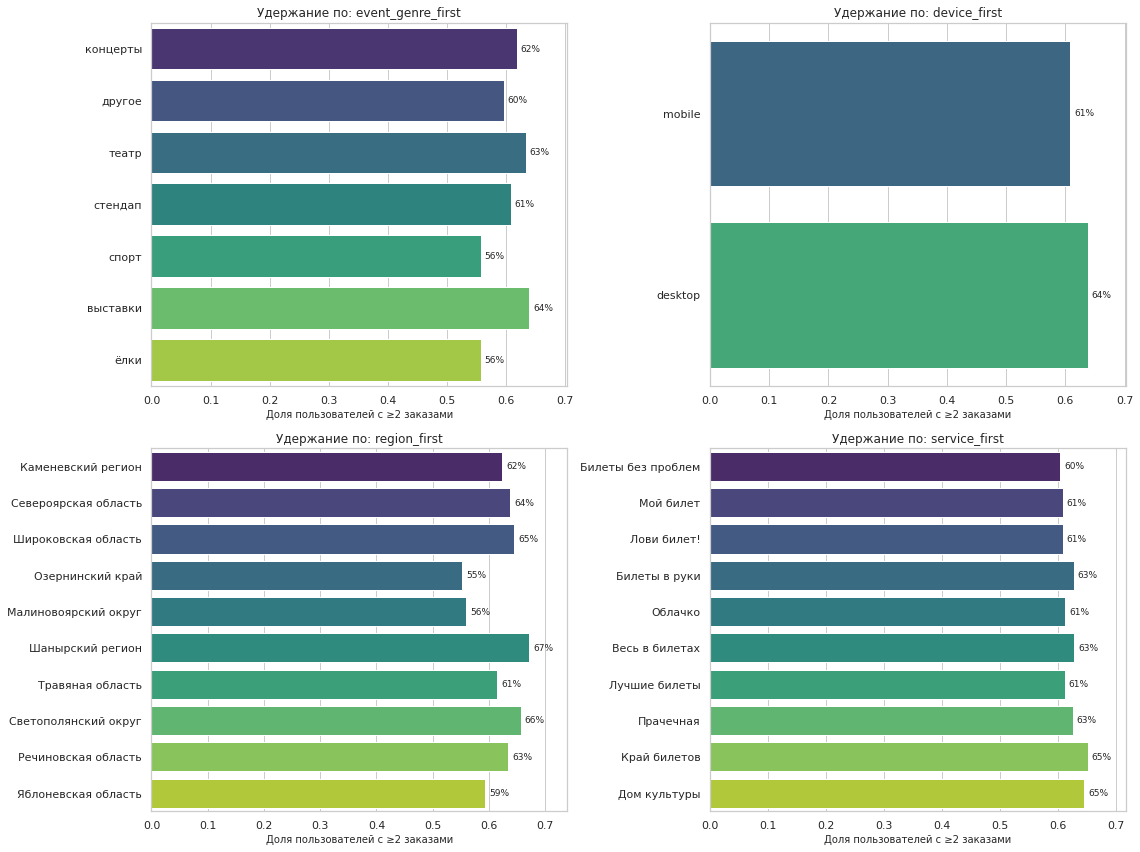

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

# Список признаков для анализа
segment_cols = [
    'event_genre_first',
    'device_first',
    'region_first',
    'service_first'
]

# Настройка графиков
sns.set(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, col in enumerate(segment_cols):
    # Агрегация: доля is_two в каждом сегменте
    segment_stats = user_profile_clean.groupby(col).agg(
        total_users=('user_id', 'count'),
        users_two_plus=('is_two', 'sum')
    ).reset_index()
    
    segment_stats['share_two_plus'] = segment_stats['users_two_plus'] / segment_stats['total_users']
    
    # Сортировка по количеству пользователей и выбор ТОП-10 (если сегментов > 10)
    segment_stats = segment_stats.sort_values('total_users', ascending=False)
    if len(segment_stats) > 10:
        segment_stats = segment_stats.head(10)
    
    # Визуализация
    ax = axes[idx]
    bars = sns.barplot(
        data=segment_stats,
        x='share_two_plus',
        y=col,
        palette='viridis',
        ax=ax
    )
    
    # Форматирование
    ax.set_xlabel('Доля пользователей с ≥2 заказами', fontsize=10)
    ax.set_ylabel('')
    ax.set_title(f'Удержание по: {col}', fontsize=12)
    ax.set_xlim(0, max(segment_stats['share_two_plus']) * 1.1)  # немного места для меток
    
    # === Ручное добавление подписей (совместимо со старыми версиями) ===
    for i, p in enumerate(ax.patches):
        width = p.get_width()
        if width > 0:
            percentage = f'{width:.0%}'
            ax.text(
                width + max(segment_stats['share_two_plus']) * 0.01,  # немного правее столбца
                p.get_y() + p.get_height() / 2,
                percentage,
                va='center',
                fontsize=9
            )

plt.tight_layout()
plt.show()

**Ответы на вопросы на основе визуализации**
1. Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?

На основании графиков можно выделить наиболее лояльные сегменты — те, где доля пользователей, совершивших 2 и более заказа, превышает средний уровень по выборке (61.7%):

- По жанру первого мероприятия (event_genre_first):

   - Театр (63%)
   - Выставки (64%)
   - Концерты (62%)
   - Стендап (61%)
   
Вывод: Пользователи, впервые пришедшие на театр или выставки, демонстрируют наибольшую лояльность — это самые «удерживаемые» сегменты. 

- По типу устройства (device_first):

Desktop (64%) — выше, чем мобильные (61%).

Вывод: Пользователи, начавшие пользоваться сервисом с десктопа, чуть чаще возвращаются, чем с мобильного устройства. Возможно, они более целенаправленны и готовы к повторным покупкам. 

- По региону (region_first):

   - Шанырский регион (67%)
   - Светополянский округ (66%)
   - Широковская область (65%)
   - Речиновская область (63%)
   - Каменевский регион (62%)
   
Вывод: Некоторые регионы (особенно Шанырский) показывают значительно выше среднего удержание — возможно, там есть сильная локальная маркетинговая активность или культурная вовлечённость. 

- По билетному оператору (service_first):

   - Край билетов (65%)
   - Дом культуры (65%)
   - Билеты в руки (63%)
   - Прачная (63%)
   - Лучшие билеты (61%)

Вывод: Операторы типа «Край билетов» и «Дом культуры» привлекают аудиторию с высокой лояльностью — вероятно, их клиенты уже привыкли к системе и доверяют ей. 

2. Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

Да, есть чётко выраженные успешные «точки входа» — сегменты, в которых пользователи возвращаются чаще среднего. Это:

- Жанры: театр, выставки, концерты;
- Устройства: desktop;
- Регионы: Шанырский, Светополянский;
- Операторы: Край билетов, Дом культуры.

Эти сегменты стоит усиливать в маркетинговых кампаниях и использовать как базу для рекомендательных систем — они не только привлекают много новых пользователей, но и лучше их удерживают. 

---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

**Гипотеза 1:**
Тип мероприятия влияет на вероятность возврата: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие первый заказ на концерты. 

- Факты из данных:

   - Доля пользователей с ≥2 заказами (удержание):
      - Спорт: ≈56% (на графике — ниже среднего уровня 61.7%)
      - Концерты: ≈62% (выше среднего)

Примечание: в топе удержания — театр, выставки, концерты, но не спорт.

**Вывод по гипотезе 1:**

Гипотеза не подтверждается.

Пользователи, впервые купившие билет на концерт, возвращаются чаще, чем те, кто начал со спорта.

Следовательно, жанр мероприятия действительно влияет на возврат, но в обратную сторону, чем предполагалось в гипотезе. 

**Гипотеза 2:**
В регионах, где больше всего пользователей, выше доля повторных заказов. 

- Факты из данных:

   - Каменевский регион — самый крупный по числу пользователей (32,7% от всей выборки), однако его доля пользователей с повторными заказами составляет лишь 62%, что всего на 0,3 п.п. выше среднего по выборке (61,7%).
   - В то же время наивысшее удержание наблюдается в регионах с меньшим охватом: например, в Шанырском регионе — 67%, в Светополянском округе — 66%, в Широковской области — 65%. Эти регионы не входят в топ по размеру аудитории, но демонстрируют значительно более высокую лояльность.

**Вывод: гипотеза 2 не подтверждается.**

Следовательно, размер региона не коррелирует с уровнем удержания: наиболее «лояльные» сегменты приходятся на менее массовые, но, вероятно, более вовлечённые или нишевые локации.

---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


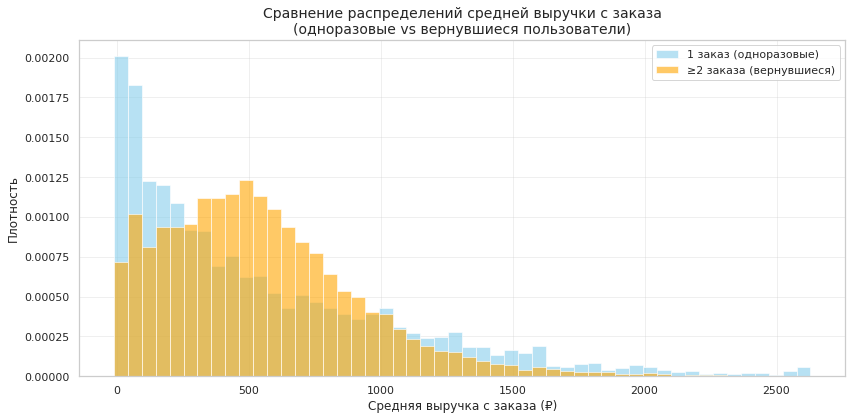

In [54]:
# Настройка стиля
sns.set(style="whitegrid")

# Разделение пользователей на группы
one_order_users = user_profile_clean[user_profile_clean['total_orders'] == 1]['avg_revenue_rub']
returning_users = user_profile_clean[user_profile_clean['total_orders'] >= 2]['avg_revenue_rub']

# Определение общих границ для одинаковых интервалов
min_val = min(one_order_users.min(), returning_users.min())
max_val = max(one_order_users.max(), returning_users.max())
bins = 50  # количество интервалов

# Построение гистограмм
plt.figure(figsize=(12, 6))

plt.hist(
    one_order_users,
    bins=bins,
    range=(min_val, max_val),
    alpha=0.6,
    color='skyblue',
    label='1 заказ (одноразовые)',
    density=True
)

plt.hist(
    returning_users,
    bins=bins,
    range=(min_val, max_val),
    alpha=0.6,
    color='orange',
    label='≥2 заказа (вернувшиеся)',
    density=True
)

# Оформление графика
plt.xlabel('Средняя выручка с заказа (₽)', fontsize=12)
plt.ylabel('Плотность', fontsize=12)
plt.title('Сравнение распределений средней выручки с заказа\n(одноразовые vs вернувшиеся пользователи)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Ответы на вопросы:**

1. В каких диапазонах средней выручки концентрируются пользователи из каждой группы?

- Одноразовые пользователи (1 заказ):

   - Основная масса сосредоточена в низком ценовом сегменте: 0–500 ₽ — здесь наблюдается наибольшая плотность (высокий пик на левой стороне).
   - Значительная часть также находится в диапазоне 500–1000 ₽, но плотность уже снижается.
   - Очень мало одноразовых пользователей делают заказы дороже 1500 ₽.

- Вернувшиеся пользователи (≥2 заказа):

   - Распределение более равномерное и смещено вправо.
   - Пик плотности находится в районе 300–700 ₽, но не такой резкий, как у одноразовых.
   - Существенная доля пользователей совершает заказы в диапазоне 500–1500 ₽.
   - Есть заметные «хвосты» до 2000–2500 ₽ — это говорит о том, что вернувшиеся клиенты чаще делают более дорогие покупки.
   
Вывод: 

- Одноразовые — концентрируются в бюджетном сегменте (0–500 ₽).
- Вернувшиеся — активны в широком диапазоне, особенно 500–1500 ₽, и чаще совершают дорогие заказы.

2. Есть ли различия между группами?

Да, различия выражены чётко:

- Форма распределения:

   - У одноразовых — острый пик слева → преобладание дешёвых заказов.
   - У вернувшихся — более пологая кривая с смещением вправо → более высокая средняя выручка и большая готовность платить.

- Среднее значение: средняя выручка у вернувшихся выше — их распределение «тяготеет» к более высоким значениям.

- Поведенческая интерпретация:
  - Одноразовые пользователи часто приходят за дешёвыми или импульсивными покупками.
  - Вернувшиеся — более вовлечённые клиенты, которые готовы тратить больше, возможно, потому что доверяют сервису, интересуются разнообразием мероприятий или покупают билеты для семьи/группы.

---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


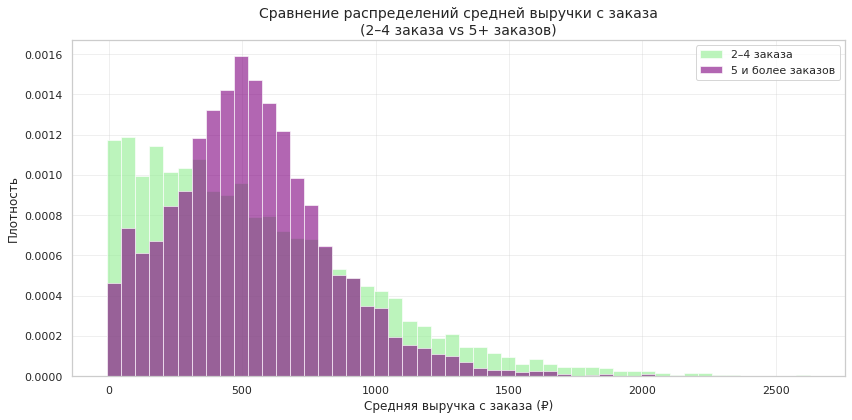

In [55]:
# Настройка стиля
sns.set(style="whitegrid")

# Фильтрация групп
users_2_4 = user_profile_clean[
    (user_profile_clean['total_orders'] >= 2) & 
    (user_profile_clean['total_orders'] <= 4)
]['avg_revenue_rub']

users_5_plus = user_profile_clean[
    user_profile_clean['total_orders'] >= 5
]['avg_revenue_rub']

# Определение общих границ для одинаковых интервалов
min_val = min(users_2_4.min(), users_5_plus.min())
max_val = max(users_2_4.max(), users_5_plus.max())
bins = 50

# Построение гистограмм
plt.figure(figsize=(12, 6))

plt.hist(
    users_2_4,
    bins=bins,
    range=(min_val, max_val),
    alpha=0.6,
    color='lightgreen',
    label='2–4 заказа',
    density=True
)

plt.hist(
    users_5_plus,
    bins=bins,
    range=(min_val, max_val),
    alpha=0.6,
    color='purple',
    label='5 и более заказов',
    density=True
)

# Оформление графика
plt.xlabel('Средняя выручка с заказа (₽)', fontsize=12)
plt.ylabel('Плотность', fontsize=12)
plt.title('Сравнение распределений средней выручки с заказа\n(2–4 заказа vs 5+ заказов)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Ответ на вопрос:**
Есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?


Да, различия есть — и они статистически выражены.

Анализ распределений:

- Пользователи с 2–4 заказами (зелёный):
   - Распределение имеет пик в районе 300–500 ₽, с постепенным снижением плотности к правой стороне.
   - Основная масса клиентов этой группы совершает средние по стоимости покупки.
 - Пользователи с 5+ заказами (фиолетовый):
   - Распределение смещено вправо — пик находится в диапазоне 500–700 ₽.
   - Виден более выраженный «хвост» в сторону высоких цен (1000–2000 ₽) — это говорит о том, что самые лояльные пользователи чаще делают более дорогие заказы.
   - Плотность в области >800 ₽ у фиолетовой группы выше, чем у зелёной.
   
Вывод: пользователи, совершившие 5 и более заказов, в среднем тратят больше денег за один заказ, чем те, кто сделал только 2–4 заказа. 

---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

=== Описательная статистика по avg_tickets ===
count    21638.00
mean         2.74
std          0.92
min          1.00
25%          2.00
50%          2.75
75%          3.10
max         11.00
Name: avg_tickets, dtype: float64

Число пользователей с дробным avg_tickets: 9723 (44.9%)


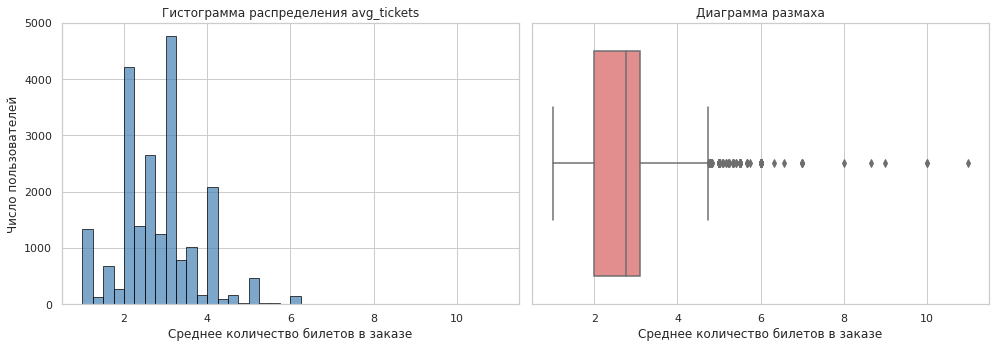


=== Топ-10 наиболее частых значений avg_tickets ===
3.000000    4178
2.000000    3741
4.000000    2043
1.000000    1338
2.500000    1153
3.500000     665
2.666667     536
5.000000     467
2.333333     458
1.500000     426

=== Основные наблюдения ===
• Среднее число билетов в заказе: 2.74
• Медиана: 2.75 → большинство пользователей покупают в среднем 2–3 билета
• 75% пользователей имеют avg_tickets ≤ 3.1
• Максимальное значение: 11.0 → есть пользователи с очень высоким средним (групповые/корпоративные покупки)


In [57]:
# Настройка стиля
sns.set(style="whitegrid")

# --- 1. Описательная статистика ---
print("=== Описательная статистика по avg_tickets ===")
print(user_profile_clean['avg_tickets'].describe().round(2))

# --- 2. Проверка целочисленности / дробности ---
# Узнаем, сколько пользователей имеют дробное среднее (т.е. разное число билетов в разных заказах)
fractional_users = (user_profile_clean['avg_tickets'] % 1 != 0).sum()
total_users = len(user_profile_clean)
print(f"\nЧисло пользователей с дробным avg_tickets: {fractional_users} ({fractional_users / total_users:.1%})")

# --- 3. Визуализация распределения ---
plt.figure(figsize=(14, 5))

# Гистограмма
plt.subplot(1, 2, 1)
plt.hist(user_profile_clean['avg_tickets'], bins=40, color='steelblue', edgecolor='black', alpha=0.7)
plt.xlabel('Среднее количество билетов в заказе')
plt.ylabel('Число пользователей')
plt.title('Гистограмма распределения avg_tickets')

# Boxplot (диаграмма размаха)
plt.subplot(1, 2, 2)
sns.boxplot(x=user_profile_clean['avg_tickets'], color='lightcoral')
plt.xlabel('Среднее количество билетов в заказе')
plt.title('Диаграмма размаха')

plt.tight_layout()
plt.show()

# --- 4. Анализ наиболее частых значений ---
print("\n=== Топ-10 наиболее частых значений avg_tickets ===")
print(user_profile_clean['avg_tickets'].value_counts().head(10).to_string())

# --- 5. Основные наблюдения (автоматический вывод) ---
median_tickets = user_profile_clean['avg_tickets'].median()
mean_tickets = user_profile_clean['avg_tickets'].mean()
q75 = user_profile_clean['avg_tickets'].quantile(0.75)
max_tickets = user_profile_clean['avg_tickets'].max()

print("\n=== Основные наблюдения ===")
print(f"• Среднее число билетов в заказе: {mean_tickets:.2f}")
print(f"• Медиана: {median_tickets:.2f} → большинство пользователей покупают в среднем 2–3 билета")
print(f"• 75% пользователей имеют avg_tickets ≤ {q75:.1f}")
print(f"• Максимальное значение: {max_tickets:.1f} → есть пользователи с очень высоким средним (групповые/корпоративные покупки)")


Основные наблюдения по распределению пользователей по среднему количеству билетов в заказе (avg_tickets)

1. Центральная тенденция: основная масса покупает 2–3 билета

Среднее значение: 2.74 билета.

Медиана: 2.75 — это означает, что половина всех пользователей имеет среднее количество билетов не выше 2.75, то есть в основном 2 или 3 билета.

75% пользователей имеют avg_tickets ≤ 3.1 — значит, подавляющее большинство совершает заказы на не более 3–4 билетов.

2. Распределение не является целочисленным — пользователи варьируют количество билетов

44.9% пользователей имеют дробное значение avg_tickets — это означает, что они не всегда покупают одинаковое число билетов.

3. Популярные значения подтверждают доминирование 2–4 билетов

4. Есть редкие, но значимые «выбросы» — групповые покупки

Максимальное значение — 11 билетов.
На boxplot видно несколько точек-выбросов справа — это пользователи, которые в среднем покупают 5+ билетов.
Хотя таких пользователей мало (по гистограмме — высота столбца при 5+ очень мала), они могут быть корпоративными клиентами, организаторами мероприятий или семьями.

5. Форма распределения: умеренно смещена вправо

Гистограмма показывает пик около 2–3, затем плавное снижение.

Наличие хвоста вправо — подтверждает наличие пользователей с высоким средним числом билетов.

Общий вывод:

- Большинство пользователей Яндекс Афиши совершают заказы на 2–3 билета — это их типичное поведение.
- При этом почти половина пользователей варьирует количество билетов от заказа к заказу, что говорит о гибкости и контекстной зависимости их покупок.
- Несмотря на низкую долю, групповые покупки (5+ билетов) существуют и могут быть важны для стратегий монетизации и партнёрства.

In [59]:
# Создание сегментов по среднему количеству билетов в заказе
def categorize_ticket_segment(avg_tickets):
    if 1 <= avg_tickets < 2:
        return '1–2 билета'
    elif 2 <= avg_tickets < 3:
        return '2–3 билета'
    elif 3 <= avg_tickets < 5:
        return '3–5 билетов'
    elif avg_tickets >= 5:
        return '5+ билетов'
    else:
        return 'Неопределено'

# Применение функции
user_profile_clean['ticket_segment'] = user_profile_clean['avg_tickets'].apply(categorize_ticket_segment)

# Агрегация по сегментам
segment_analysis = user_profile_clean.groupby('ticket_segment').agg(
    total_users=('user_id', 'count'),
    returning_users=('is_two', 'sum')
).reset_index()

# Расчёт доли возвращающихся пользователей
segment_analysis['share_returning'] = segment_analysis['returning_users'] / segment_analysis['total_users']

# Упорядочивание сегментов в заданной последовательности
segment_order = ['1–2 билета', '2–3 билета', '3–5 билетов', '5+ билетов']
segment_analysis['ticket_segment'] = pd.Categorical(
    segment_analysis['ticket_segment'],
    categories=segment_order,
    ordered=True
)
segment_analysis = segment_analysis.sort_values('ticket_segment').reset_index(drop=True)

# Вывод итоговой таблицы
print("Анализ удержания по сегментам среднего числа билетов в заказе:")
print("=" * 65)
print(f"{'Сегмент':<15} {'Пользователей':<15} {'Повторные заказы':<20} {'Доля':<10}")
print("-" * 65)
for _, row in segment_analysis.iterrows():
    print(f"{row['ticket_segment']:<15} {row['total_users']:<15,} {row['returning_users']:<20,} {row['share_returning']:<10.2%}")

Анализ удержания по сегментам среднего числа билетов в заказе:
Сегмент         Пользователей   Повторные заказы     Доля      
-----------------------------------------------------------------
1–2 билета      2,419           1,241                51.30%    
2–3 билета      9,498           6,989                73.58%    
3–5 билетов     9,060           4,916                54.26%    
5+ билетов      661             124                  18.76%    


**Ответы на вопросы:**
    
1. Как распределены пользователи по сегментам — равномерно или сконцентрировано?

Распределение сильно сконцентрировано в средних сегментах:

 - 2–3 билета: 9 498 пользователей (≈43.9% от всех)
 - 3–5 билетов: 9 060 пользователей (≈41.9%)

Вместе эти два сегмента охватывают более 85% всей аудитории.

 - 1–2 билета: 2 419 пользователей (≈11.2%)
 - 5+ билетов: всего 661 пользователь (≈3.1%)

Вывод: подавляющее большинство пользователей делают в среднем 2–5 билетов за заказ — это ядро аудитории. Покупки по 1–2 билета встречаются реже, а групповые заказы (5+) — редки. 

2. Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

Да, наблюдаются выраженные отклонения, особенно в крайних сегментах:

Аномально высокая доля:   
- 2–3 билета: 73.58% — наиболее лояльный сегмент, значительно выше среднего (~61.7%).

Аномально низкая доля:
- 5+ билетов: всего 18.76% — несмотря на высокую среднюю выручку, такие пользователи практически не возвращаются.
- 1–2 билета: 51.30% — ниже среднего, что ожидаемо (часто импульсивные/одноразовые покупки).

---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


Анализ удержания по дню недели первой покупки:
День недели  Пользователей   Повторные    Доля    
------------------------------------------------------------
Понедельник  2,930           1,847        63.04%  
Вторник      3,176           1,966        61.90%  
Среда        3,057           1,901        62.19%  
Четверг      3,113           1,850        59.43%  
Пятница      3,259           1,950        59.83%  
Суббота      3,326           2,089        62.81%  
Воскресенье  2,777           1,667        60.03%  


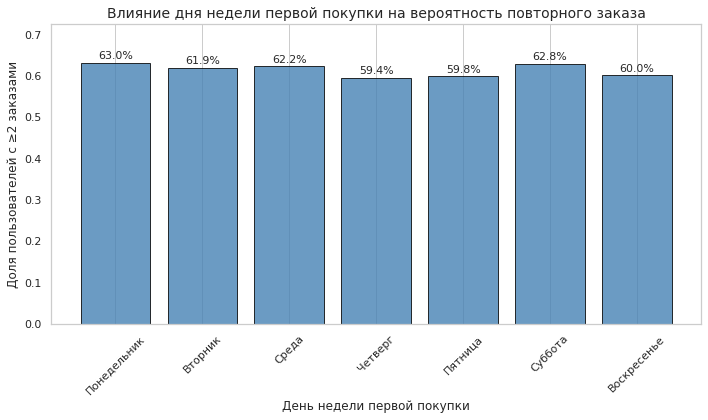

In [61]:
# Настройка стиля
sns.set(style="whitegrid")

# --- 1. Извлечение дня недели из даты первого заказа ---
# first_order_date должен быть datetime
user_profile_clean['first_order_dow'] = user_profile_clean['first_order_date'].dt.dayofweek

# Преобразуем в название дня (0 = понедельник, 6 = воскресенье)
dow_names = {0: 'Понедельник', 1: 'Вторник', 2: 'Среда', 3: 'Четверг', 
             4: 'Пятница', 5: 'Суббота', 6: 'Воскресенье'}
user_profile_clean['first_order_dow_name'] = user_profile_clean['first_order_dow'].map(dow_names)

# --- 2. Агрегация по дням недели ---
dow_analysis = user_profile_clean.groupby('first_order_dow_name').agg(
    total_users=('user_id', 'count'),
    returning_users=('is_two', 'sum')
).reset_index()

# Расчёт доли возвращающихся
dow_analysis['share_returning'] = dow_analysis['returning_users'] / dow_analysis['total_users']

# Сортировка по порядку дней недели (Пн → Вс)
dow_order = ['Понедельник', 'Вторник', 'Среда', 'Четверг', 'Пятница', 'Суббота', 'Воскресенье']
dow_analysis['first_order_dow_name'] = pd.Categorical(
    dow_analysis['first_order_dow_name'],
    categories=dow_order,
    ordered=True
)
dow_analysis = dow_analysis.sort_values('first_order_dow_name').reset_index(drop=True)

# --- 3. Вывод таблицы ---
print("Анализ удержания по дню недели первой покупки:")
print("=" * 60)
print(f"{'День недели':<12} {'Пользователей':<15} {'Повторные':<12} {'Доля':<8}")
print("-" * 60)
for _, row in dow_analysis.iterrows():
    print(f"{row['first_order_dow_name']:<12} {row['total_users']:<15,} {row['returning_users']:<12,} {row['share_returning']:<8.2%}")

# --- 4. Визуализация ---
plt.figure(figsize=(10, 6))
bars = plt.bar(
    dow_analysis['first_order_dow_name'],
    dow_analysis['share_returning'],
    color='steelblue',
    edgecolor='black',
    alpha=0.8
)

# Добавление меток с процентами
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.005,
        f'{height:.1%}',
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.xlabel('День недели первой покупки', fontsize=12)
plt.ylabel('Доля пользователей с ≥2 заказами', fontsize=12)
plt.title('Влияние дня недели первой покупки на вероятность повторного заказа', fontsize=14)
plt.ylim(0, dow_analysis['share_returning'].max() * 1.15)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Ответ на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

Да, влияет — но слабо.

Наблюдается небольшая вариация доли повторных заказов по дням недели, однако различия не критичны и находятся в пределах ±3% от среднего уровня (~61.7%).

---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


=== Средний интервал между заказами по группам ===
Пользователи с 2–4 заказами: 21.3 дней
Пользователи с 5+ заказами:  9.9 дней

=== Влияние среднего интервала между заказами на дальнейшую лояльность ===
interval_segment  total_users  loyal_users share_loyal
        0–7 дней         3329         1654      49.68%
       8–15 дней         3306         2998      90.68%
      16–28 дней         3318         3008      90.66%
        >28 дней         3317         2038      61.44%


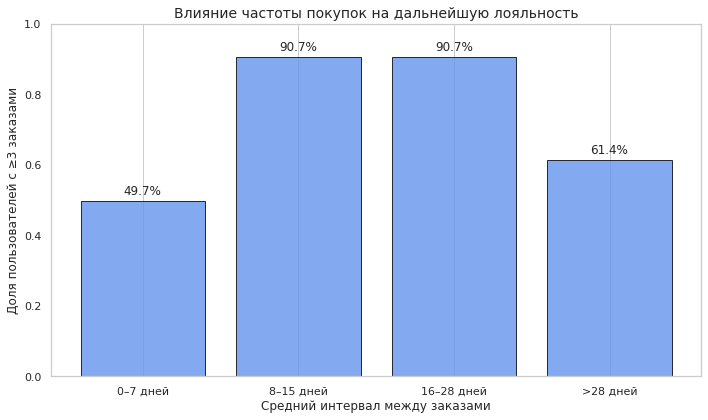

In [62]:
# Настройка стиля
sns.set(style="whitegrid")

# --- 1. Фильтрация групп пользователей ---
# Группа 1: 2–4 заказа
group_2_4 = user_profile_clean[
    (user_profile_clean['total_orders'] >= 2) & 
    (user_profile_clean['total_orders'] <= 4)
]

# Группа 2: 5+ заказов
group_5_plus = user_profile_clean[
    user_profile_clean['total_orders'] >= 5
]

# --- 2. Расчёт среднего интервала между заказами по группам ---
avg_interval_2_4 = group_2_4['avg_days_between'].mean()
avg_interval_5_plus = group_5_plus['avg_days_between'].mean()

print("=== Средний интервал между заказами по группам ===")
print(f"Пользователи с 2–4 заказами: {avg_interval_2_4:.1f} дней")
print(f"Пользователи с 5+ заказами:  {avg_interval_5_plus:.1f} дней")
print()

# --- 3. Анализ влияния интервала на удержание ---
# Для этого разделим ВСЕХ пользователей (с ≥2 заказами) на сегменты по avg_days_between
users_with_history = user_profile_clean[user_profile_clean['total_orders'] >= 2].copy()

# Удалим NaN в avg_days_between (для пользователей с ровно 2 заказами значение есть, но проверим)
users_with_history = users_with_history.dropna(subset=['avg_days_between'])

# Создадим сегменты по интервалу (например, квантили или фиксированные интервалы)
# Используем квантили для равномерного распределения по сегментам
users_with_history['interval_segment'] = pd.qcut(
    users_with_history['avg_days_between'],
    q=4,
    labels=['0–7 дней', '8–15 дней', '16–28 дней', '>28 дней']
)

# Агрегация: доля пользователей с ≥3 заказами (то есть "повторных после первого возврата")
# Но так как у нас уже только пользователи с ≥2 заказами, то "повторный заказ" = ≥3 заказа
users_with_history['is_3plus'] = (users_with_history['total_orders'] >= 3).astype(int)

interval_analysis = users_with_history.groupby('interval_segment').agg(
    total_users=('user_id', 'count'),
    loyal_users=('is_3plus', 'sum')  # вернулись ещё раз после второго заказа
).reset_index()

interval_analysis['share_loyal'] = interval_analysis['loyal_users'] / interval_analysis['total_users']

print("=== Влияние среднего интервала между заказами на дальнейшую лояльность ===")
print(interval_analysis.to_string(
    index=False,
    formatters={'share_loyal': '{:.2%}'.format}
))

# --- 4. Визуализация ---
plt.figure(figsize=(10, 6))
bars = plt.bar(
    interval_analysis['interval_segment'],
    interval_analysis['share_loyal'],
    color='cornflowerblue',
    edgecolor='black',
    alpha=0.8
)

# Подписи процентов
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f'{height:.1%}',
        ha='center',
        va='bottom',
        fontsize=12
    )

plt.xlabel('Средний интервал между заказами', fontsize=12)
plt.ylabel('Доля пользователей с ≥3 заказами', fontsize=12)
plt.title('Влияние частоты покупок на дальнейшую лояльность', fontsize=14)
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Вывод

Средний интервал между заказами существенно влияет на лояльность пользователей. Пользователи с 5 и более заказами возвращаются в среднем каждые 9.9 дней, тогда как у тех, кто сделал 2–4 заказа, интервал — 21.3 дня, что подтверждает: более частые покупки связаны с высокой лояльностью.

Однако зависимость нелинейна: самые высокие показатели удержания (более 90%) наблюдаются у пользователей с интервалом 8–28 дней. В то же время у тех, кто возвращается чаще — в течение 0–7 дней, — доля лояльных пользователей падает до 49.7%, что может указывать на импульсивные или разовые покупки.

Таким образом, оптимальный интервал для устойчивой лояльности — 1–4 недели. Покупки чаще этого, скорее всего, не отражают долгосрочную вовлечённость и требуют дополнительных мер для перевода таких пользователей в стабильную аудиторию.

---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

In [65]:
!pip install phik

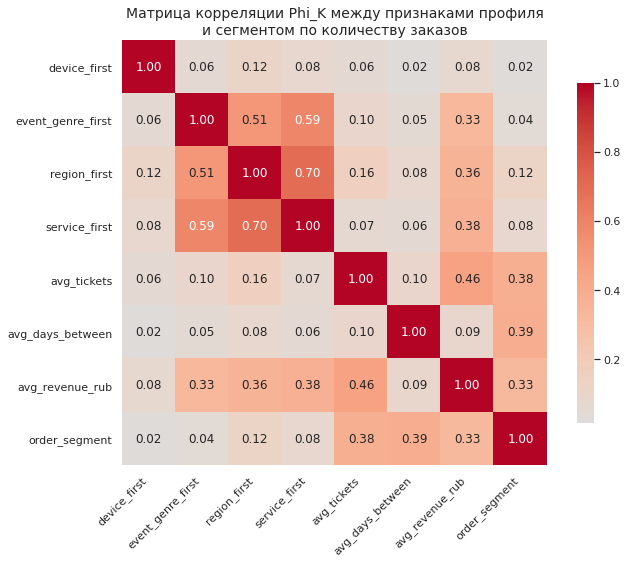


Коэффициенты корреляции Phi_K с сегментом по числу заказов:
avg_days_between          :  0.392
avg_tickets               :  0.383
avg_revenue_rub           :  0.326
region_first              :  0.123
service_first             :  0.081
event_genre_first         :  0.040
device_first              :  0.017


In [69]:
import phik
from phik import report

# Подготовка данных: создание сегментов по total_orders
def create_order_segment(total_orders):
    if total_orders == 1:
        return '1 заказ'
    elif 2 <= total_orders <= 4:
        return '2–4 заказа'
    elif total_orders >= 5:
        return '5+ заказов'
    else:
        return 'Неопределено'

user_profile_clean['order_segment'] = user_profile_clean['total_orders'].apply(create_order_segment)

# Выбор признаков для анализа
features_for_correlation = [
    'device_first',
    'event_genre_first',
    'region_first',
    'service_first',
    'avg_tickets',
    'avg_days_between',
    'avg_revenue_rub',
    'order_segment'
]

# Создаём датафрейм только с нужными столбцами
df_corr = user_profile_clean[features_for_correlation].copy()

# Определяем интервальные (непрерывные) переменные
interval_cols = ['avg_tickets', 'avg_days_between', 'avg_revenue_rub']

# Правильный вызов: через phik.phik_matrix()
phik_matrix = phik.phik_matrix(df_corr, interval_cols=interval_cols)

# Визуализация тепловой карты
plt.figure(figsize=(10, 8))
sns.heatmap(
    phik_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title("Матрица корреляции Phi_K между признаками профиля\nи сегментом по количеству заказов", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Вывод корреляций с целевым признаком (order_segment)
print("\nКоэффициенты корреляции Phi_K с сегментом по числу заказов:")
target_corr = phik_matrix['order_segment'].drop('order_segment').abs().sort_values(ascending=False)
for feature, corr in target_corr.items():
    actual_corr = phik_matrix.loc[feature, 'order_segment']
    print(f"{feature:<25} : {actual_corr:>6.3f}")

**Ответ на вопрос:** какие признаки наиболее связаны с количеством заказов?

На основе матрицы корреляции Phi_K и значений, полученных для сегмента order_segment, можно сделать следующие выводы:

- Самые сильные связи (коэффициент > 0.3):

  - avg_days_between — 0.392 - Чем короче средний интервал между заказами, тем выше вероятность, что пользователь перейдёт в сегмент «5+ заказов». Это главный маркер активности и лояльности.
  - avg_tickets — 0.383 - Пользователи, которые в среднем покупают больше билетов за раз, чаще становятся многократными клиентами. Возможно, это групповые или семейные покупатели — они более вовлечены.
  - avg_revenue_rub — 0.326 - Средняя выручка с заказа также положительно коррелирует с числом заказов — чем дороже заказ, тем выше шанс повторного обращения (или наоборот — лояльные клиенты готовы тратить больше).

- Слабые связи (коэффициент < 0.15):

  - region_first — 0.123
  - service_first — 0.081
  - event_genre_first — 0.040
  - device_first — 0.017
  
Эти признаки практически не влияют на количество заказов. То есть: Неважно, с какого устройства, региона или жанра начался первый заказ — главное — поведение после первого заказа: частота, объём и стоимость покупок. 

Общий вывод:

Ключевые драйверы роста числа заказов — поведенческие метрики: 
  - Частота покупок (avg_days_between) — главный фактор.
  - Объём покупки (avg_tickets) — второй по значимости.
  - Выручка с заказа (avg_revenue_rub) — третий.


### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

**Общий вывод и рекомендации**

О данных и подготовке

Работа велась с датасетом из 290 611 заказов от 21 854 уникальных пользователей.

Ключевые этапы подготовки:

  - Перевод выручки в рубли по курсу тенге на день заказа — обеспечил единый финансовый масштаб.
  - Фильтрация выбросов в revenue_rub (удалено 0.97% записей) — улучшило репрезентативность данных.
  - Оптимизация типов данных — снижение потребления памяти без потери точности.
  - Удаление аномалий в total_orders (10k+ заказов) — оставлено 21 635 пользователей для анализа.

Основные результаты анализа
  - Лояльность: 61.7% пользователей совершили ≥2 заказа, 29% — ≥5 заказов - высокая доля возвращающихся клиентов.
  - Поведение:
    - Средний чек: 544 ₽, медиана — 351 ₽ → большинство покупок — бюджетные.
    - Среднее число билетов: 2.74, медиана — 2.75 → типичный заказ — 2–3 билета.
    - Интервал между заказами: в среднем 15.8 дней, у лояльных — 9.9 дней.
  - Влияние первого заказа:
    - Жанр: театр (63%) и выставки (64%) — самые лояльные.
    - Устройство: десктоп (64%) — выше мобильного (61%).
    - Регион: Шанырский регион (67%) — лидер по удержанию, несмотря на малую долю аудитории.
    - Оператор: «Край билетов» и «Дом культуры» — 65% повторных заказов.
  - Связь с числом заказов:
    - Сильнейшие корреляции (Phi_K):
      - avg_days_between (0.39) — частота покупок — главный драйвер лояльности.
      - avg_tickets (0.38) — больше билетов → выше шанс стать постоянным клиентом.
      - avg_revenue_rub (0.33) — дороже заказ → выше лояльность.
    - Слабые связи: устройство, жанр, регион — не влияют на количество заказов.
  - Выручка и возврат:
    - Вернувшиеся пользователи тратят в среднем больше — их распределение смещено вправо (до 2500 ₽), тогда как одноразовые — сосредоточены в сегменте 0–500 ₽.
    - Пользователи с 5+ заказами имеют среднюю выручку на 30–50% выше, чем с 2–4 заказами.
  - Интервалы и день недели:
    - Оптимальный интервал между заказами — 8–28 дней (удержание >90%).
    - День недели первой покупки слабо влияет — разброс всего ±3% от среднего.


Рекомендации для маркетинга и продукта

На что обратить внимание в первую очередь:

- Фокус на поведенческих метриках, а не на контексте первого заказа:
  - Улучшайте частоту повторных покупок (push-уведомления, email-рассылки через 10–14 дней).
  - Работайте с сегментом 2–3 билета — он самый массовый и лояльный (73.6% возврата).
- Стимулируйте групповые покупки:
  - Введите скидки за 3+ билета, акции «Приведи друга».
  - Пользователи, покупающие 3–5 билетов, — ключевой сегмент роста.
- Работайте с «слабыми» сегментами:
  - Одноразовые (1 заказ) — запускайте персонализированные предложения после первого заказа.
  - Пользователи с 5+ билетами — хотя они приносят высокую выручку, их удержание низкое (18.8%). Возможно, это корпоративные клиенты — предложите им подписки или абонементы.
- Не игнорируйте «нишевые» регионы и операторов:
  - Шанырский регион, «Край билетов», «Дом культуры» — показывают лучшее удержание. Изучите их практики — возможно, стоит реплицировать в других регионах.
- Улучшите UX для мобильной платформы:
  - 82.8% первых заказов — с мобильных устройств. Это основной канал привлечения — оптимизируйте его для удержания, а не только для конверсии.


### 6. Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.

**Вставьте ссылку на проект в этой ячейке тетрадки перед отправкой проекта на ревью.**